## Model Building
### Approach
- Handle class imbalance using SMOTE
- Build Logistic Regression as baseline
- Evaluate using ROC-AUC (industry standard for healthcare ML)

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from imblearn.over_sampling import SMOTE

import warnings

warnings.filterwarnings("ignore")

### Load Data

In [2]:
df = pd.read_csv("diabetic_ml_ready.csv")

X = df.drop(columns=["high_risk"])
y = df["high_risk"]

print("Features shape:", X.shape)
print("Target distribution:")
print(y.value_counts())
print(f"\nPositive class: {y.mean()*100:.1f}%")

Features shape: (101766, 66)
Target distribution:
high_risk
0    90409
1    11357
Name: count, dtype: int64

Positive class: 11.2%


###  Train/Test Split BEFORE SMOTE

In [3]:
# CRITICAL: Split BEFORE applying SMOTE
# SMOTE should only be applied on training data
# If SMOTE is applied before splitting, test data gets contaminated

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())

Training set: (81412, 66)
Test set: (20354, 66)

Training target distribution:
high_risk
0    72326
1     9086
Name: count, dtype: int64


### Apply SMOTE on training data only

In [4]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", X_train.shape, "| Positive:", y_train.sum())
print("After SMOTE :", X_train_smote.shape, "| Positive:", y_train_smote.sum())
print("\nAfter SMOTE target distribution:")
print(pd.Series(y_train_smote).value_counts())
print("Now perfectly balanced!")

Before SMOTE: (81412, 66) | Positive: 9086
After SMOTE : (144652, 66) | Positive: 72326

After SMOTE target distribution:
high_risk
0    72326
1    72326
Name: count, dtype: int64
Now perfectly balanced!


### Train Logistic Regression

In [5]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_smote, y_train_smote)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression trained!")

Logistic Regression trained!


### Evaluate

In [6]:
print("=" * 45)
print("     LOGISTIC REGRESSION RESULTS")
print("=" * 45)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_lr):.4f}")
print()
print(classification_report(y_test, y_pred_lr))

     LOGISTIC REGRESSION RESULTS
Accuracy  : 0.7679
Precision : 0.1381
Recall    : 0.2061
F1 Score  : 0.1654
ROC-AUC   : 0.5452

              precision    recall  f1-score   support

           0       0.89      0.84      0.87     18083
           1       0.14      0.21      0.17      2271

    accuracy                           0.77     20354
   macro avg       0.52      0.52      0.52     20354
weighted avg       0.81      0.77      0.79     20354



### Confusion Matrix

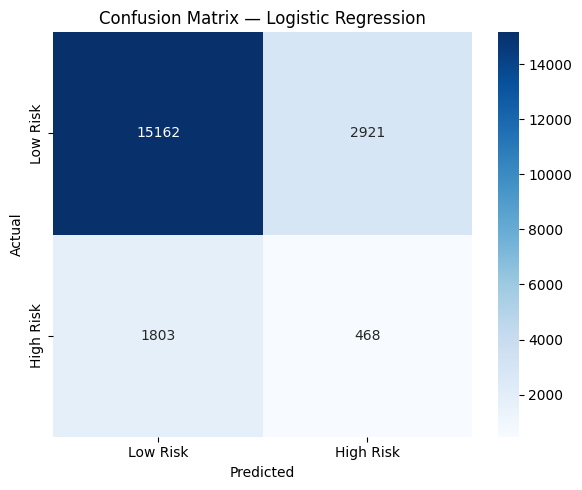


True Negatives  (correctly said Low Risk) : 15,162
False Positives (wrongly flagged High Risk): 2,921
False Negatives (missed High Risk patients): 1,803
True Positives  (correctly caught High Risk): 468

In healthcare, False Negatives are most costly!
We missed 1,803 high-risk patients who were not flagged.


In [7]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"],
)
plt.title("Confusion Matrix — Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("images/confusion_matrix_lr.png")
plt.show()

# Explain what the numbers mean
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly said Low Risk) : {tn:,}")
print(f"False Positives (wrongly flagged High Risk): {fp:,}")
print(f"False Negatives (missed High Risk patients): {fn:,}")
print(f"True Positives  (correctly caught High Risk): {tp:,}")
print(f"\nIn healthcare, False Negatives are most costly!")
print(f"We missed {fn:,} high-risk patients who were not flagged.")

###  ROC Curve

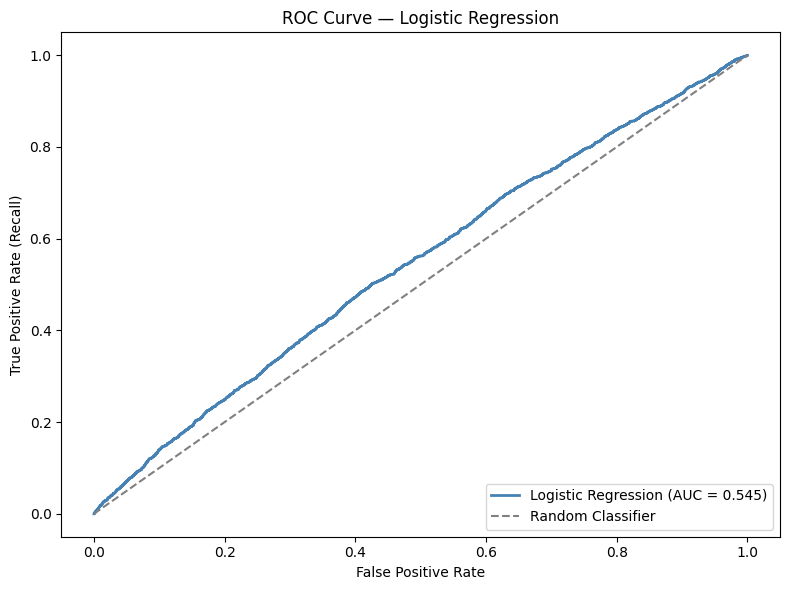

In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
auc = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr, tpr, color="steelblue", lw=2, label=f"Logistic Regression (AUC = {auc:.3f})"
)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Logistic Regression")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("images/roc_curve_lr.png")
plt.show()

## Day 3 Summary — Logistic Regression Baseline

### Key Decisions
- Applied SMOTE AFTER train/test split (critical — prevents data leakage)
- SMOTE balanced training set from 8:1 → 1:1 ratio
- Using ROC-AUC as primary metric (better than accuracy for imbalanced data)

### Why ROC-AUC matters here
- With 88.8% negative class, a model predicting ALL negatives gets 88.8% accuracy
- ROC-AUC measures TRUE discriminative ability regardless of class balance
- AUC of 0.5 = random, AUC of 1.0 = perfect

### Healthcare Context
- False Negatives (missed high-risk patients) are most costly
- A hospital would rather over-flag (false positive) than miss a real case

### Results
- Logistic Regression ROC-AUC: 0.545 — barely above random
- This is expected — linear model struggles with 66 complex 
  clinical features and non-linear relationships
- Recall of 20.6% means we miss 79.4% of high-risk patients
- This establishes our baseline — tree-based models should 
  significantly improve ROC-AUC
- Next: Random Forest — expected ROC-AUC 0.65-0.75